# Parliamentarians

Tim Sherratt

What do we know about the people whose words are recorded in Hansard?
The [*Parliamentary Handbook*](https://handbook.aph.gov.au) provides a
wealth of information on the make up of the Australian Parliament,
including biographical details of all parliamentarians from 1901. The
*Parliamentary Handbook* includes a [simple
API](../hansard/parliamentary-handbook-api.ipynb) that you can use to
get the data about parliamentarians in machine-readable form.

Once we have the data we can slice it in different ways to gain some
understanding of the make up of parliament.

## Gender

The data from the *Parliamentary Handbook* includes a field for
`Gender`. We can aggregate data from this field to generate some
overviews.

In [3]:
gender_total = df["Gender"].value_counts().to_frame().reset_index()
gender_house = df.loc[df["ElectedMemberNo"] > -1]["Gender"].value_counts().to_frame().reset_index()
gender_senate = df.loc[df["ElectedSenatorNo"] > -1]["Gender"].value_counts().to_frame().reset_index()
gender_total

In [4]:
# Create the base chart
gender_base = alt.Chart().encode(
    theta=alt.Theta("count").stack(True),
    color=alt.Color("Gender").legend(None),
    tooltip=[alt.Tooltip("count", title="number of parliamentarians"), alt.Tooltip("Gender", title="gender")]
).properties(width="container")

# Both houses
total_base = gender_base.properties(data=gender_total)
# Create the pie segments
total_pie = total_base.mark_arc()
# Create the text labels
total_text = total_base.mark_text(radius=170, size=12).encode(text="Gender:N")
# Combine pie and labels
chart_total = alt.layer(total_pie, total_text, padding=20)

# House of Reps
house_base = gender_base.properties(data=gender_house)
house_pie = house_base.mark_arc(outerRadius=120)
house_text = house_base.mark_text(radius=140, size=12).encode(text="Gender:N")
chart_house = alt.layer(house_pie, house_text, padding=20)

# Senate
senate_base = gender_base.properties(data=gender_senate)
senate_pie = senate_base.mark_arc(outerRadius=120)
senate_text = senate_base.mark_text(radius=140, size=12).encode(text="Gender:N")
chart_senate = alt.layer(senate_pie, senate_text, padding=20)

# Need to display all charts together like this for Quarto to lay them out
display(chart_total, chart_house, chart_senate)

Every federal election results in a new ‘parliament’, and each
parliament is given a consecutive number. So the very first parliamant
was number `1`. The parliamentarians data includes a list of the
parliaments that each member was a part of. We can use this to explore
how the gender composition of the parliament has changed over time.

In [5]:
# Explode to create a row for each parliament
df_parls = df.explode("RepresentedParliaments", ignore_index=True)

parl_gender_base = alt.Chart().mark_bar().encode(
    x=alt.X("parls:O").title("parliament number"),
    y=alt.Y("count:Q").title("number of members").stack(True),
    color="Gender",
    tooltip=[alt.Tooltip("parls", title="parliament"), alt.Tooltip("Gender", title="gender"), alt.Tooltip("count", title="number of members")]
).properties(width="container")

parl_gender = df_parls.value_counts(["Gender", "RepresentedParliaments"]).to_frame().reset_index()
parl_gender.columns = ["Gender", "parls", "count"]
parl_gender_chart = parl_gender_base.properties(data=parl_gender)

display(parl_gender_chart)

The aggregated data from the Parliamentary Handbook doesn’t specify
which house a member was in during a particular parliament. To find
that, we can compare their service details with the dates of each
parliament. Once we’ve split the parliaments data into houses, we can
chart the gender breakdown by house.

In [6]:
# Load data about parliaments
df_parl_dates = pd.read_json("https://handbookapi.aph.gov.au/api/StatisticalInformation/Parliaments", convert_dates=["DateElection", "DateDissolution"])

def is_in_range(dates, parl_num):
    """
    Checks to see if the supplied date range overlaps with the date range of the specified parliament
    """
    # Parliament dates
    date_start, date_end = list(df_parl_dates.iloc[df_parl_dates["Number"] == parl_num][["DateElection", "DateDissolution"]].values[0])
    # Service dates to test for overlap
    test_dates = [datetime.fromisoformat(d) for d in dates]
    if pd.notnull(date_end):
        return date_start <= test_dates[1] and date_end >= test_dates[0]
    else:
        return date_start <= test_dates[1] and datetime.now() >= test_dates[0]

def check_dates(dates, parls):
    """
    Compares a list of service dates with the dates of the supplied parliaments.
    Returns a list of parliaments ids that overlap.
    """
    checked_parls = []
    for parl_num in parls:
        for date in dates:
            if is_in_range(date, parl_num):
                checked_parls.append(parl_num)
    return list(set(checked_parls))

def find_house_parliaments(row):
    """
    Try to identify which house a member was in for the list of parliaments in the `RepresentedParliaments` field.
    """
    # Members who only served in one house
    if len(row["MPorSenator"]) == 1:
        if row["MPorSenator"][0] == "Member":
            house_parls = row["RepresentedParliaments"]
            senate_parls = []
        else:
            senate_parls = row["RepresentedParliaments"]
            house_parls = []
    # Members who served in both houses
    else:
        senate_dates = []
        house_dates = []
        # Get service records, these don't say what house they relate to
        services = row["PartyParliamentaryService"]
        # Get electorate records, these obviously are for Reps only
        electorates = row["ElectorateService"]
        elec_dates = [e["ServiceStart"] for e in electorates]
        # Looks for matches between the dates of service records and elecorate records
        # If the dates match then the service record relates to Reps,
        # otherwise it's a Senate record.
        for service in services:
            if service["DateStart"] in elec_dates:
                house_dates.append([service["DateStart"], service["DateEnd"]])
            else:
                senate_dates.append([service["DateStart"], service["DateEnd"]])
        # Get parliaments that overlap with service records
        house_parls = check_dates(house_dates, row["RepresentedParliaments"])
        senate_parls = check_dates(senate_dates, row["RepresentedParliaments"])
        
    return pd.Series([house_parls, senate_parls])

df[["house_parls", "senate_parls"]] = df.apply(find_house_parliaments, axis=1)

df_house_parls = df.explode("house_parls", ignore_index=True)
df_senate_parls = df.explode("senate_parls", ignore_index=True)

parl_gender_house = df_house_parls.value_counts(["Gender", "house_parls"]).to_frame().reset_index()
parl_gender_house.columns = ["Gender", "parls", "count"]
parl_gender_house_chart = parl_gender_base.properties(data=parl_gender_house, height=200)

parl_gender_senate = df_senate_parls.value_counts(["Gender", "senate_parls"]).to_frame().reset_index()
parl_gender_senate.columns = ["Gender", "parls", "count"]
parl_gender_senate_chart = parl_gender_base.properties(data=parl_gender_senate, height=200)
parl_gender_senate_chart.encoding.y = parl_gender_senate_chart.encoding.y.scale(domain=(0, 160))

display(parl_gender_house_chart, parl_gender_senate_chart)

## Age

How old are the members of parliament?

In [7]:
def get_opening_date(sessions):
    """
    Get the opening date of the first session of a parliament.
    """
    starting_dates = []
    for session in sessions:
        starting_dates.append(session["DateOpening"])
    return pd.to_datetime(sorted(starting_dates)[0])

# Add date for opening of first session
df_parl_dates["opening"] = df_parl_dates["Sessions"].apply(get_opening_date)
df_parl_openings = df_parl_dates[["Number", "opening"]]

def calculate_age(row):
    """
    Calculate the age of a member at the opening of parliament.
    """
    opening = row["opening"]
    born = row["DateOfBirth"]
    return opening.year - born.year - ((opening.month, opening.day) < (born.month, born.day))

# Combine members data with pdates of parliaments
df_parls_ages = pd.merge(df_parls, df_parl_openings, how="left", left_on="RepresentedParliaments", right_on="Number")
# Convert birthdate to datetime
df_parls_ages["DateOfBirth"] = pd.to_datetime(df_parls_ages["DateOfBirth"], format='ISO8601')
# Add age
df_parls_ages["age"] = df_parls_ages.apply(calculate_age, axis=1)

# Aggregate age data for each parliamant -- mean, max and min ages
parl_ages = df_parls_ages.groupby(["Number", "opening"])["age"].agg(["mean", "min", "max"]).reset_index()

# Base chart with parliaments
age_base = alt.Chart(parl_ages).encode(
    x=alt.X("Number:O").title("parliament number"),
).properties(width="container")

# Show mean of ages as line chart
mean_ages = age_base.mark_line(point=True).encode(
    y=alt.Y("mean:Q").scale(domain=(40, 60)).title("mean age of members"),
    tooltip=[alt.Tooltip("Number", title="parliament"), alt.Tooltip("opening", title="opening date"), alt.Tooltip("mean", title="mean of ages")]
).properties(width="container")

# Show max/min ages as area chart
age_intervals = age_base.mark_area(opacity=0.2).encode(
    alt.Y("max:Q").scale(domain=(20, 90)),
    alt.Y2("min:Q"),
    tooltip=[alt.Tooltip("Number", title="parliament"), alt.Tooltip("opening", title="opening date"), alt.Tooltip("mean", title="mean of ages"), "max", "min"]
).properties(width="container")

display(mean_ages, age_intervals + mean_ages)

## Country of birth

In [8]:
country_counts = df["CountryOfBirth"].value_counts().to_frame().reset_index()
country_counts.columns = ["country of birth", "number of members"]
country_counts.style.format(thousands=",").hide()

## Occupations

In [9]:
number_with_occupations = df.loc[(df["Occupations"].str.len() > 0) | (df["SecondaryOccupations"].str.len() > 0)].shape[0]

The Parliamentary Handbook records information about the occupations of
members in the `Occupations` and `SecondaryOccupations` fields. However,
not all members have occupations recorded. Currently 87% of member
records include information about occupations.

Here’s a word cloud generated from the contents of both fields.

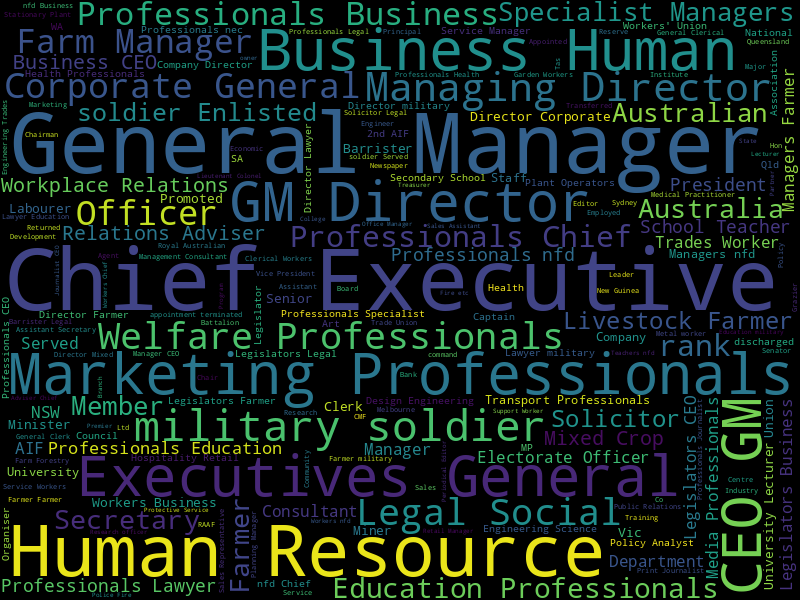

In [10]:
from wordcloud import WordCloud

occupations = []
for field in ["Occupations", "SecondaryOccupations"]:
    # Flatten nested lists into one list
    occupations += [o for occs in df[field].to_list() for o in occs]

wc = WordCloud(width=800, height=600).generate(" ".join(occupations))
wc.to_image()

## Political parties

The aggregated data lists the political parties that each
parliamentarian has been a member of. We can use this to find the total
number of members associated with each party. Note that parties changed
names, and politicians changed parties, so a single individual might be
counted multiple times.

In [11]:
party_counts = df.explode("RepresentedParties")["RepresentedParties"].value_counts().to_frame().reset_index()
party_counts.columns = ["party", "number of members"]
party_counts.style.format(thousands=",").hide()

The data also lists the parties associated with each period of a
member’s parliamentary service. We can use this to aggregate the party
counts by parliament and observe changes in the political make up of the
parliament over time – for example the rise of the two party system.
Once again, if a member changed parties, or belonged to a party that
changed its name within a the period of a parliament, they could be
counted multiple times.

In [12]:
def get_parties_parliaments(row):
    services = row["PartyParliamentaryService"]
    for service in services:
        dates = [service["DateStart"], service["DateEnd"]]
        if is_in_range(dates, row["RepresentedParliaments"]):
            parties = [p["Value"] for p in service["SecondaryService"]]
            return list(set(parties))

df_parls["parties"] = df_parls.apply(get_parties_parliaments, axis=1)
df_parls_parties = df_parls.explode("parties")
party_counts = df_parls_parties.value_counts(["RepresentedParliaments", "parties"]).to_frame().reset_index()

alt.Chart(party_counts).mark_bar().encode(
    x=alt.X("RepresentedParliaments:O").title("parliament number"),
    y=alt.Y("count:Q").title("number of members").stack("normalize"),
    color=alt.Color("parties:N", sort=alt.EncodingSortField('count', op='mean', order='descending')).scale(scheme="category20"),
    tooltip=[alt.Tooltip("RepresentedParliaments:O", title="parliament"), alt.Tooltip("count:Q", title="number of members"), alt.Tooltip("parties", title="party")]
).properties(width="container", height=500, padding=20)